In [ ]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Save model
import pickle

In [ ]:
df=pd.read_csv(r'/content/fair_recrutment_dataset final.csv')
df

,Candidate_ID,Gender,Age,Education_Level,Experience_Years,Skill_Score,Aptitude_Test_Score,Technical_Test_Score,Communication_Score,Certifications_Count,Previous_Companies,Interview_Score,Location,Job_Role_Applied,Expected_Salary,Hiring_Decision
0,1,Male,50,Bachelors,19,48,75,70,65,2.0,5,92,Urban,HR Executive,22214,1
1,2,Other,36,Bachelors,18,9,53,46,25,2.0,4,77,Semi-Urban,Data Analyst,130094,0
2,3,Female,58,Masters,11,1,85,62,72,1.0,3,90,Urban,ML Engineer,78652,0
3,4,Male,48,Masters,0,74,35,79,67,6.0,3,9,Urban,HR Executive,144618,0
4,5,Male,37,Bachelors,0,64,99,25,38,7.0,5,24,Urban,Data Analyst,133865,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121195,47344,Male,37,Bachelors,17,71,55,56,80,8.0,2,70,Urban,Data Analyst,44867,1
121196,111198,Male,49,Masters,14,84,60,99,9,9.0,1,64,Urban,Software Engineer,103035,1
121197,52991,Female,37,Diploma,12,49,59,64,26,8.0,5,89,Urban,Manager,99111,1
121198,101228,Male,41,Bachelors,18,29,15,78,29,3.0,7,22,Semi-Urban,ML Engineer,51287,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121200 entries, 0 to 121199
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Candidate_ID          121200 non-null  int64  
 1   Gender                121190 non-null  object 
 2   Age                   121200 non-null  int64  
 3   Education_Level       121190 non-null  object 
 4   Experience_Years      121200 non-null  int64  
 5   Skill_Score           121200 non-null  int64  
 6   Aptitude_Test_Score   121200 non-null  int64  
 7   Technical_Test_Score  121200 non-null  int64  
 8   Communication_Score   121200 non-null  int64  
 9   Certifications_Count  121190 non-null  float64
 10  Previous_Companies    121200 non-null  int64  
 11  Interview_Score       121200 non-null  int64  
 12  Location              121200 non-null  object 
 13  Job_Role_Applied      121200 non-null  object 
 14  Expected_Salary       121200 non-null  int64  
 15  

In [ ]:
df.describe(include='all')

,Candidate_ID,Gender,Age,Education_Level,Experience_Years,Skill_Score,Aptitude_Test_Score,Technical_Test_Score,Communication_Score,Certifications_Count,Previous_Companies,Interview_Score,Location,Job_Role_Applied,Expected_Salary,Hiring_Decision
count,121200.000000,121190,121200.000000,121190,121200.000000,121200.000000,121200.000000,121200.000000,121200.000000,121190.000000,121200.000000,121200.000000,121200,121200,121200.000000,121200.000000
unique,NaN,3,NaN,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,5,NaN,NaN
top,NaN,Male,NaN,Bachelors,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Urban,ML Engineer,NaN,NaN
freq,NaN,72664,NaN,48576,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,67011,24562,NaN,NaN
mean,59996.388036,NaN,40.050206,NaN,9.507368,49.612863,49.394365,49.501658,49.472921,4.496972,3.513152,49.384678,NaN,NaN,84880.884538,0.257624
std,34639.833443,NaN,11.278150,NaN,5.774991,28.875296,28.915583,28.878555,28.888881,2.876632,2.288319,28.870584,NaN,NaN,37503.647943,0.437327
min,1.000000,NaN,21.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,20000.000000,0.000000
25%,30009.750000,NaN,30.000000,NaN,4.000000,25.000000,24.000000,24.000000,24.000000,2.000000,2.000000,24.000000,NaN,NaN,52403.000000,0.000000
50%,59989.500000,NaN,40.000000,NaN,10.000000,50.000000,49.000000,49.000000,50.000000,4.000000,4.000000,49.000000,NaN,NaN,84840.500000,0.000000
75%,89991.250000,NaN,50.000000,NaN,15.000000,75.000000,74.000000,75.000000,75.000000,7.000000,6.000000,74.000000,NaN,NaN,117374.250000,1.000000


In [ ]:
df.isnull().sum()/len(df)*100

,0
Candidate_ID,0.000000
Gender,0.008251
Age,0.000000
Education_Level,0.008251
Experience_Years,0.000000
Skill_Score,0.000000
Aptitude_Test_Score,0.000000
Technical_Test_Score,0.000000
Communication_Score,0.000000
Certifications_Count,0.008251


### We have null values in Gender, Education Level, Certifications Count.

In [ ]:
for i in df.columns:
  print(i,df[i].unique())

Candidate_ID [     1      2      3 ... 119998 119999 120000]
Gender ['Male' 'Other' 'Female' nan]
Age [50 36 58 48 37 59 39 27 38 46 55 28 24 41 47 42 43 23 51 34 45 21 56 44
 31 33 32 29 30 22 26 54 49 25 52 35 53 40 57]
Education_Level ['Bachelors' 'Masters' 'High School' 'Diploma' 'PhD' nan]
Experience_Years [19 18 11  0 10  4  2  3  1 14 13 17  9  7 15  5 12  8 16  6]
Skill_Score [48  9  1 74 64 92 39 83 53 55 28 12 85 29  2 46 49 58 52 68 77 99 82 26
 87 18 71  7  3 66 75 14 13  0 23 38 40 84 96 19 86 73 93 25 30  4 56 59
 21 95 11 63 15 34 16 78 27 47 97 98 10 65 32 36 60 61  5 50 51 90 44 70
 22 37 33 91 67 31  8 24 80 81 54 17 45 42 69 79 94 35 20 41 89 62  6 57
 88 43 76 72]
Aptitude_Test_Score [75 53 85 35 99 95 57 20 13 98  4 26 18 68  0 21 25 31 23 78 39 29 36 96
  7 46 30 82 22 73 79 34  1 52 90 64 80 15 44 77 40 56 94 91 76 48 55 81
 69 10 83 32  9 51 17 28 24 47 45 50 38  3 42 37 27 12 89 72 86 71 49 33
 19  6 93 67  5 88 97 14  2 60 54 74 62  8 63 61 43 87 84 41 59 70 9

### We don't have any wrong format data.

In [ ]:
cat_col=['Gender','Education_Level']
for i in cat_col:
  df[i].fillna(df[i].mode()[0],inplace=True)

/tmp/ipykernel_11786/3437160559.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[i].fillna(df[i].mode()[0],inplace=True)


### I have filled categorical null value with mode.

In [ ]:
df['Certifications_Count']=df['Certifications_Count'].fillna(df['Certifications_Count'].mean())

### The numerical null values are filled with mean value.

In [ ]:
df.isnull().sum()

,0
Candidate_ID,0
Gender,0
Age,0
Education_Level,0
Experience_Years,0
Skill_Score,0
Aptitude_Test_Score,0
Technical_Test_Score,0
Communication_Score,0
Certifications_Count,0


### Now, there is not any null values in data.

In [ ]:
df.duplicated().sum()

np.int64(1199)

### We have duplicate values in data.

In [ ]:
df.drop_duplicates(inplace=True,keep='first')

### I have removed duplicate value from data.

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in df.columns:
    if df[col].dtype == "object":
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        encoders[col] = le
print(encoders.keys())

dict_keys(['Gender', 'Education_Level', 'Location', 'Job_Role_Applied'])


In [ ]:
df.head()

,Candidate_ID,Gender,Age,Education_Level,Experience_Years,Skill_Score,Aptitude_Test_Score,Technical_Test_Score,Communication_Score,Certifications_Count,Previous_Companies,Interview_Score,Location,Job_Role_Applied,Expected_Salary,Hiring_Decision
0,1,1,50,0,19,48,75,70,65,2.0,5,92,2,1,22214,1
1,2,2,36,0,18,9,53,46,25,2.0,4,77,1,0,130094,0
2,3,0,58,3,11,1,85,62,72,1.0,3,90,2,2,78652,0
3,4,1,48,3,0,74,35,79,67,6.0,3,9,2,1,144618,0
4,5,1,37,0,0,64,99,25,38,7.0,5,24,2,0,133865,0


In [ ]:
df.drop('Candidate_ID',axis=1,inplace=True)

In [ ]:
df['Hiring_Decision'].value_counts()

,count
Hiring_Decision,
0,89108
1,30893


### As we can see 0 class has 89108 value & class 1 has 30893 value it shows data imbalancement issue.

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
x = df.drop("Hiring_Decision",axis=1)
y = df["Hiring_Decision"]

In [ ]:
smote = SMOTE(random_state=42)
x_resampled, y_resampled = smote.fit_resample(x, y)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x_resampled, y_resampled,
    test_size=0.2,
    random_state=42
)

In [ ]:
lr = LogisticRegression()

lr.fit(x_train, y_train)

y_pred_lr = lr.predict(x_test)

print("Logistic Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Accuracy: 0.8337167545729997


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
print(classification_report(y_test, y_pred_lr))
print('Accuracy:', accuracy_score(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.87      0.78      0.82     17702
           1       0.81      0.88      0.84     17942

    accuracy                           0.83     35644
   macro avg       0.84      0.83      0.83     35644
weighted avg       0.84      0.83      0.83     35644

Accuracy: 0.8337167545729997


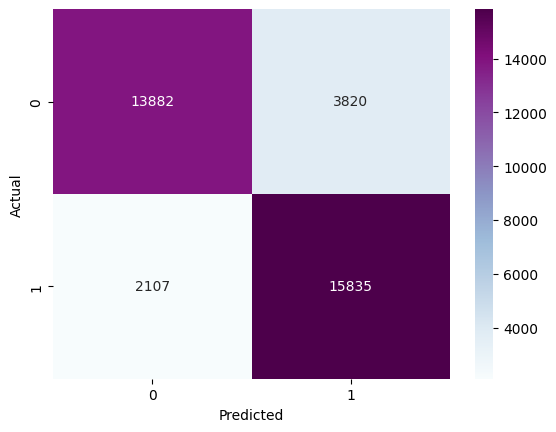

In [ ]:
cfm=confusion_matrix(y_test,y_pred_lr)
sns.heatmap(cfm,annot=True,fmt='g',cmap='BuPu')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### My logistic regression model is giving 83 % accuracy which is good.

In [ ]:
dt = DecisionTreeClassifier()

dt.fit(x_train, y_train)

y_pred_dt = dt.predict(x_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9679048367186623


In [ ]:
print(classification_report(y_test, y_pred_dt))
print('Accuracy:', accuracy_score(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97     17702
           1       0.97      0.97      0.97     17942

    accuracy                           0.97     35644
   macro avg       0.97      0.97      0.97     35644
weighted avg       0.97      0.97      0.97     35644

Accuracy: 0.9679048367186623


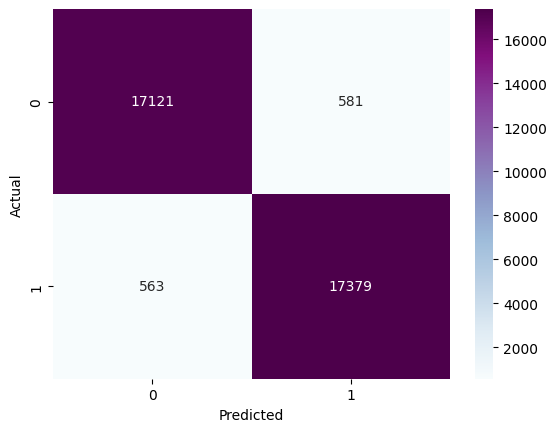

In [ ]:
cfm=confusion_matrix(y_test,y_pred_dt)
sns.heatmap(cfm,annot=True,fmt='g',cmap='BuPu')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Decision tree model accuracy is 96.66 % i.e. very good.

In [ ]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.9637526652452025


In [ ]:
print(classification_report(y_test, y_pred_rf))
print('Accuracy:', accuracy_score(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.98      0.95      0.96     17702
           1       0.95      0.98      0.96     17942

    accuracy                           0.96     35644
   macro avg       0.96      0.96      0.96     35644
weighted avg       0.96      0.96      0.96     35644

Accuracy: 0.9637526652452025


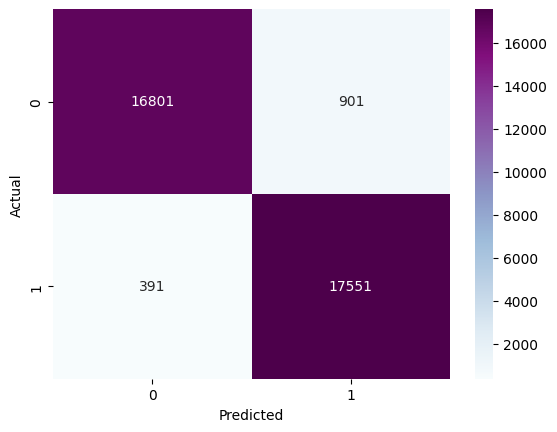

In [ ]:
cfm=confusion_matrix(y_test,y_pred_rf)
sns.heatmap(cfm,annot=True,fmt='g',cmap='BuPu')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Random forest model is giving accuracy of 96.37%

### Decision tree model is giving very good accuracy.
### So, I will go with decision tree model for prediction.

In [ ]:
import pickle

pickle.dump(dt, open("decision_tree_model.pkl","wb"))
pickle.dump(encoders, open("encoders.pkl","wb"))

In [ ]:
print(encoders.keys())

dict_keys(['Gender', 'Education_Level', 'Location', 'Job_Role_Applied'])


In [1]:
%%writefile app.py
import gradio as gr
import numpy as np
import pickle

dt = pickle.load(open("decision_tree_model.pkl","rb"))
encoders = pickle.load(open("encoders.pkl","rb"))
print("Files loaded successfully")

dt = pickle.load(open("decision_tree_model.pkl","rb"))
encoders = pickle.load(open("encoders.pkl","rb"))

print("Files loaded successfully")
def predict_candidate(
    Gender,
    Age,
    Education_Level,
    Experience_Years,
    Skill_Score,
    Aptitude_Test_Score,
    Technical_Test_Score,
    Communication_Score,
    Certifications_Count,
    Previous_Companies,
    Interview_Score,
    Location,
    Job_Role_Applied,
    Expected_Salary
):

    try:

        Gender = encoders["Gender"].transform([Gender])[0]
        Education_Level = encoders["Education_Level"].transform([Education_Level])[0]
        Location = encoders["Location"].transform([Location])[0]
        Job_Role_Applied = encoders["Job_Role_Applied"].transform([Job_Role_Applied])[0]

        input_data = np.array([[

            Gender,
            Age,
            Education_Level,
            Experience_Years,
            Skill_Score,
            Aptitude_Test_Score,
            Technical_Test_Score,
            Communication_Score,
            Certifications_Count,
            Previous_Companies,
            Interview_Score,
            Location,
            Job_Role_Applied,
            Expected_Salary

        ]])

        prediction = dt.predict(input_data)

        if prediction[0] == 1:
            return "Candidate Selected ✅"
        else:
            return "Candidate Not Selected ❌"

    except Exception as e:
        return str(e)


interface = gr.Interface(

    fn=predict_candidate,

    inputs=[

        gr.Radio(["Male","Female","Other"], label="Gender"),

        gr.Number(label="Age"),

        gr.Dropdown(["Diploma","Bachelors","Masters","PhD"],
        label="Education Level"),

        gr.Number(label="Experience Years"),

        gr.Slider(0,100,label="Skill Score"),

        gr.Slider(0,100,label="Aptitude Test Score"),

        gr.Slider(0,100,label="Technical Test Score"),

        gr.Slider(0,100,label="Communication Score"),

        gr.Number(label="Certifications Count"),

        gr.Number(label="Previous Companies"),

        gr.Slider(0,100,label="Interview Score"),

        gr.Radio(["Urban","Semi-Urban","Rural"],
        label="Location"),

        gr.Dropdown(["HR Executive","Data Analyst",
        "ML Engineer","Software Engineer",'Manager'],
        label="Job Role Applied"),

        gr.Number(label="Expected Salary")

    ],

    outputs="text",

    title="Hiring Decision Prediction System",

    description="Decision Tree Model Prediction App"

)

interface.launch()

Overwriting app.py


In [ ]:
%%writefile requirements.txt
gradio
numpy
joblib
scikit-learn

Writing requirements.txt
